# Metagenomic Analyses of the Longitudinal Acne Study
## Relative Abundance Plots

Date created: 10/17/2024

Notebook author: Yang Chen

Data analysis by: Yang Chen and Britta De Pessemier

This notebook plots the following:

- Metagenomic relative abundance plots of metagenome assembled genomes from a subset of acne lesional and non-lesional samples

In [17]:
# Import Python packages
import pandas as pd
import numpy as np
import biom
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import os
from matplotlib.colors import ListedColormap


In [18]:
# Switch this to Genus to make the Genus level plots and Species to make the  plots
# taxa_level = 'Genus'
taxa_level = 'Species'

In [19]:
# Load the metadata
metadata_path = '../Metadata/metadata_final_18062024.tsv'
metadata = pd.read_csv(metadata_path, sep='\t')

In [20]:
# Define paths to the collapsed taxa tables
biom_paths = {
    # 'veba_MAGs_genus': '../Data/metaG/Tables/metaG_mags_genus.biom',
    'veba_MAGs_species': '../Data/metaG/Tables/metaG_mags_species.biom'
    # 'qiita_wolr2' : '../Data/metaG/Tables/metaG_wolr2_micov-filt_speces.biom',
    # 'qiita_rs210' : '../Data/metaG/Tables/metaG_rs210_micov-filt_speces.biom',
    # 'qiita_rs210': '../Data/metaG/Tables/metaG_rs210_micov-filt_species.biom'}
}

In [21]:
# Predefined color palette for specific families
taxa_colors = {
    ' s__Cutibacterium acnes': '#ffa505',  # Bright orange
    ' s__Malassezia spp.': '#ec8cbf',     # Light purple pink
    ' s__Lawsonella cleavelandensis': '#70a8dc',      # Light blue
    ' s__Corynebacterium spp.': '#92f0f0',      # Fluorescent light blue
    ' s__Streptococcus spp.': '#e2b46c',    # Beige
    ' s__Micrococcus luteus': '#ffe59a',        # Pastel yellow
    ' s__Neisseria cerebrosa': '#f6475f',         # Redish pink
    ' s__Porphyromonas pasteri': '#c5bce0',         # Pastel purplish
    ' s__Actinomyces spp.': '#f4cccd',  # Light pink
    ' s__Alloprevotella spp.': '#bcbcbc',  # Light gray
    ' s__Psychrobacter spp.': '#daead3',  # Light greenish gray
    ' s__Marinomonas spp.' : '#9FE2BF', # Seafoam green
    'Others': '#ededed'                 # White
}

In [22]:
# A list of unique colors to use for taxa not predefined
unique_colors = sns.color_palette("deep", n_colors=20).as_hex()
unique_color_iter = cycle(unique_colors)  # Iterator to cycle through unique colors

In [23]:
# Function to load BIOM table, collapse by taxa, and sort rows by row sum
def load_biom_table(biom_path):
    table = biom.load_table(biom_path)
    df = pd.DataFrame(table.matrix_data.toarray(),
                      index=table.ids(axis='observation'),
                      columns=table.ids(axis='sample'))
    
    # Sort rows by row sum in descending order
    df['row_sum'] = df.sum(axis=1)
    df = df.sort_values(by='row_sum', ascending=False)
    
    # Drop the 'row_sum' column before returning
    df = df.drop(columns=['row_sum'])
    
    return df

In [24]:
# Function to determine the top 15 in taxa level and collapse the rest as "Others"
def collapse_top_10(df):
    top_families = df.sum(axis=1).nlargest(10).index  # Select top 15 families
    df_top = df.loc[top_families]
    df_top.loc['Others'] = df.loc[~df.index.isin(top_families)].sum()
    return df_top

In [25]:
# Function to get or assign colors to families
def get_taxa_colors(families, global_taxa_color_map):
    for taxa in families:
        if taxa not in global_taxa_color_map:
            if taxa in taxa_colors:
                global_taxa_color_map[taxa] = taxa_colors[taxa]
            else:
                global_taxa_color_map[taxa] = next(unique_color_iter)  # Assign a new unique color
    return global_taxa_color_map

In [26]:
def plot_relative_abundance(df, metadata, group_column, output_dir, biom_key, taxa_color_map):
    # Average by group
    df_grouped = df.groupby(metadata[group_column], axis=1).mean()
    
    # Reorder the columns to Acne Non-lesional then Lesional
    desired_order = ['Acne_NL', 'Acne_L']
    df_grouped = df_grouped[desired_order]

    # Create output file paths
    output_png_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.png')  # Save as png
    output_svg_file = os.path.join(output_dir, f'{biom_key}_{taxa_level}_relative_abundance_plot.svg')  # Save as svg

    # Set plot title based on biom_key
    if biom_key == 'veba_MAGs_species':
        plot_title = f'metaG Relative Abundance'
    elif biom_key == 'qiita_wolr2':
        plot_title = f'metaG wolr2 {taxa_level} Level Relative Abundance'
    elif biom_key == 'qiita_rs210':
        plot_title = f'metaG rs210 {taxa_level} Level Relative Abundance'
    elif biom_key == 'veba_MAGs':
        plot_title = f'metaG {taxa_level} Level Relative Abundance'

    # Plot
    ax = df_grouped.T.plot(kind='bar', stacked=True, figsize=(10, 10),
                           width=0.8,  # Bars closer together
                           color=[taxa_color_map.get(fam, '#ADD8E6') for fam in df_grouped.index])

    plt.ylabel('Relative Abundance', fontsize=18)
    plt.xlabel(' ')
    plt.title(plot_title, fontsize=16)

    new_labels = ['Acne\nNon-lesional\n(n=12)', 'Acne\nLesional\n(n=12)']

    # Set the new x-tick labels
    plt.xticks(ticks=range(len(new_labels)), labels=new_labels, rotation=0, ha='center', fontsize=16)

    plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=16)
    plt.tight_layout()

    plt.savefig(output_png_file, format='png', dpi=600)  # Save as png
    plt.savefig(output_svg_file, format='svg')  # Save as svg
    plt.show()

    plt.close()


In [27]:
# Switch this to Genus to make the Genus level plots and Species to make the  plots
# taxa_level = 'Genus'
taxa_level = 'Species'

In [28]:
# Define paths to the collapsed taxa tables
biom_paths = {
    'veba_MAGs': '../Data/metaG/Tables/metaG_mags_species.biom'}

In [29]:
# Predefined color palette for specific families
taxa_colors = {
    ' s__Cutibacterium acnes': '#ffa505',  # Bright orange
    ' s__Malassezia spp.': '#ec8cbf',     # Light purple pink
    ' s__Lawsonella cleavelandensis': '#70a8dc',      # Light blue
    ' s__Corynebacterium spp.': '#92f0f0',      # Fluorescent light blue
    ' s__Streptococcus spp.': '#e2b46c',    # Beige
    ' s__Micrococcus luteus': '#ffe59a',        # Pastel yellow
    ' s__Neisseria cerebrosa': '#f6475f',         # Redish pink
    ' s__Porphyromonas pasteri': '#c5bce0',         # Pastel purplish
    ' s__Actinomyces spp.': '#f4cccd',  # Light pink
    ' s__Alloprevotella spp.': '#bcbcbc',  # Light gray
    ' s__Psychrobacter spp.': '#daead3',  # Light greenish gray
    ' s__Marinomonas spp.' : '#9FE2BF', # Seafoam green
    'Others': '#ededed'                 # White
}

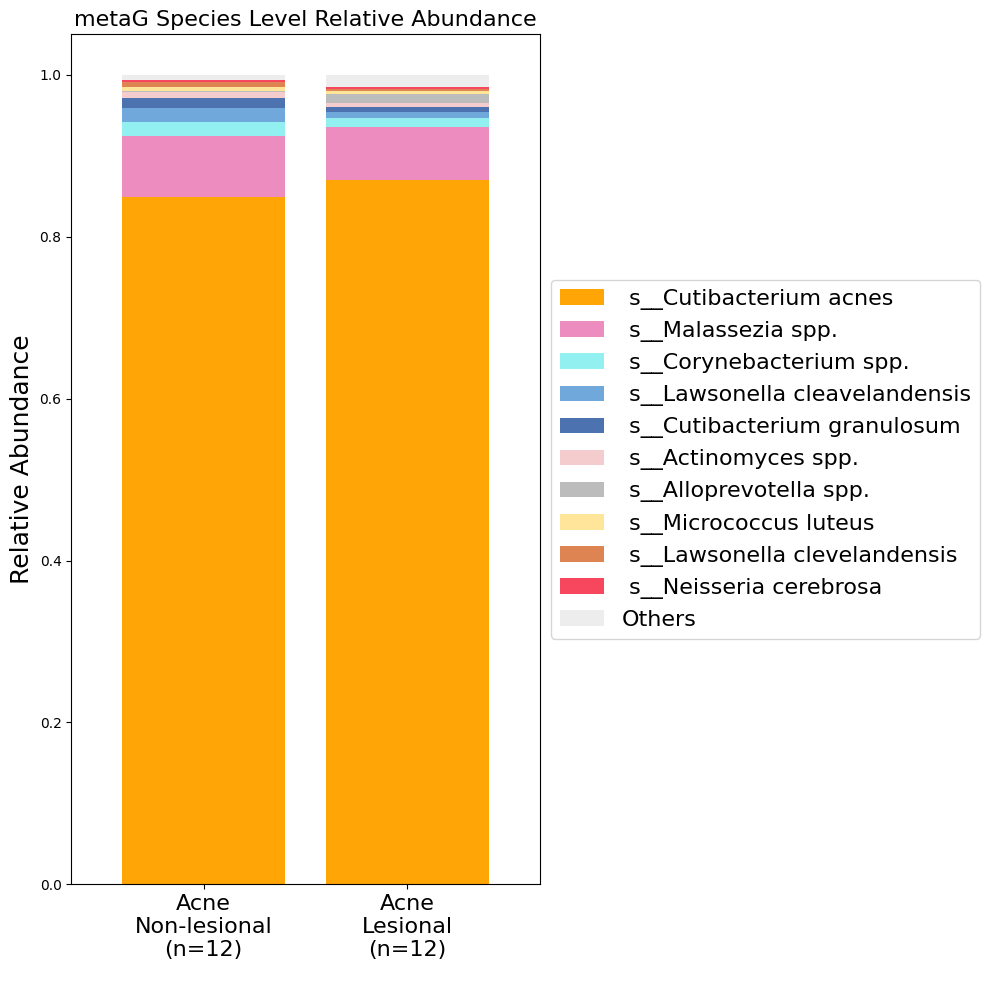

In [30]:
# Process both BIOM files
global_taxa_color_map = {}  # Store colors assigned to families across both datasets
for biom_key, biom_path in biom_paths.items():
    # Load and process the BIOM table
    df = load_biom_table(biom_path)
    df_top_10 = collapse_top_10(df)  # Now using the top 15 function
    
    # Define the output directory for the current biom_key
    output_dir = '../Figures/metaG_Figures'
    os.makedirs(output_dir, exist_ok=True)  # Ensure the output directory exists
    
    # Merge with metadata
    metadata_subset = metadata.set_index('SampleID').loc[df.columns]  # Assuming SampleID in metadata matches samples in BIOM table
    
    # Generate or retrieve colors for the top families in this dataset
    global_taxa_color_map = get_taxa_colors(df_top_10.index, global_taxa_color_map)
    
    # Plot the results and save in the respective folder 
    plot_relative_abundance(df_top_10, metadata_subset, 'group', output_dir, biom_key, global_taxa_color_map)